# Heston Model: Hedging Under Stochastic Volatility

Extends the BS hedging analysis to Heston. The main questions:

- What happens when you hedge with BS deltas but reality follows Heston?
- Does using the "correct" Heston delta actually help?
- What risk can't you hedge away with stock alone?

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from utils import Heston_CF, Heston_price
from greeks.cos_greeks import cos_greeks_full, bs_greeks_analytical

np.random.seed(42)

## Heston Model Recap

Under Heston {cite:p}`Heston1993`, stock and variance follow:

$$dS_t = r S_t \, dt + \sqrt{v_t} S_t \, dW_t^S$$
$$dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_t^v$$

with $\text{Corr}(dW^S, dW^v) = \rho$.

The parameters: $v_0$ is initial variance, $\theta$ is long-run variance, $\kappa$ controls mean-reversion speed, $\xi$ is vol-of-vol, and $\rho$ is typically negative (the leverage effect—when stock drops, vol tends to rise).

For hedging, the key difference from BS is that volatility is now a second source of randomness. Option prices depend on the current vol level, and that level moves around.

In [ ]:
# Heston parameters
S0 = 100
K = 100
T = 0.25
r = 0.05

v0 = 0.04        # Initial variance (vol = 20%)
theta = 0.04     # Long-run variance
kappa = 2.0      # Mean-reversion speed
xi = 0.3         # Vol-of-vol
rho = -0.7       # Correlation (leverage effect)

sigma_bs = np.sqrt(v0)  # Equivalent BS vol for comparison

print("Model Parameters")
print("="*40)
print(f"Spot S0:          {S0}")
print(f"Strike K:         {K}")
print(f"Time T:           {T} years")
print(f"Risk-free r:      {r}")
print(f"Initial vol:      {100*np.sqrt(v0):.1f}%")
print(f"Long-run vol:     {100*np.sqrt(theta):.1f}%")
print(f"Vol-of-vol xi:    {xi}")
print(f"Correlation rho:  {rho}")

## Heston Greeks via COS Method

Under Heston, Greeks need to be computed numerically. We use the COS method {cite:p}`FangOosterlee2008`—analytical derivatives for delta/gamma, finite differences for vega and theta.

The important difference from BS: Heston delta depends on the current variance $v_t$, not just spot. Even if spot doesn't move, delta changes as vol moves around.

In [ ]:
# Compare BS vs Heston Greeks
bs_g = bs_greeks_analytical(S0, K, T, r, sigma_bs, 'call')
heston_g = cos_greeks_full(S0, K, T, r, v0, model='heston', N=256, L=12,
                           opt_type='call', heston_cf=Heston_CF,
                           kappa=kappa, theta=theta, xi=xi, rho=rho)

print("Greeks Comparison: BS vs Heston")
print("="*50)
print(f"{'Greek':<12} {'BS':>12} {'Heston':>12} {'Diff %':>12}")
print("-"*50)
for g in ['price', 'delta', 'gamma', 'theta', 'vega']:
    bs_val = bs_g[g]
    h_val = heston_g[g]
    diff_pct = 100 * (h_val - bs_val) / abs(bs_val) if bs_val != 0 else 0
    print(f"{g.capitalize():<12} {bs_val:>12.6f} {h_val:>12.6f} {diff_pct:>11.2f}%")

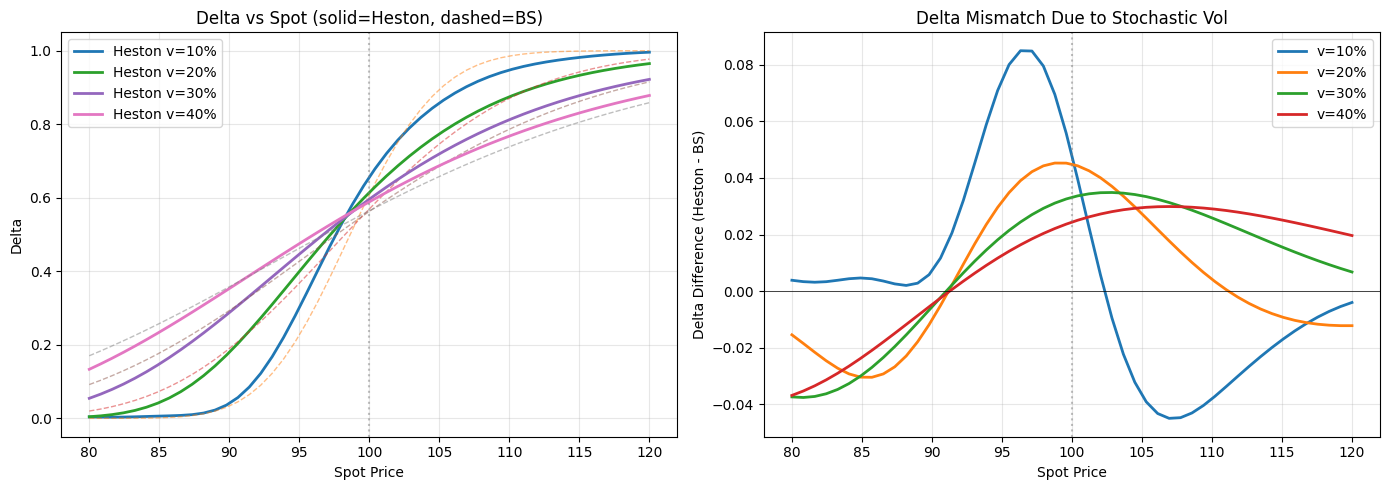

In [17]:
# Delta as function of spot and vol
spots = np.linspace(80, 120, 50)
vols = [0.01, 0.04, 0.09, 0.16]  # 10%, 20%, 30%, 40%

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Delta vs Spot for different vol levels
ax = axes[0]
for v in vols:
    deltas_heston = []
    deltas_bs = []
    for s in spots:
        h_g = cos_greeks_full(s, K, T, r, v, model='heston', N=256, L=12,
                              heston_cf=Heston_CF, kappa=kappa, theta=theta, xi=xi, rho=rho)
        b_g = bs_greeks_analytical(s, K, T, r, np.sqrt(v), 'call')
        deltas_heston.append(h_g['delta'])
        deltas_bs.append(b_g['delta'])
    ax.plot(spots, deltas_heston, '-', label=f'Heston v={100*np.sqrt(v):.0f}%', linewidth=2)
    ax.plot(spots, deltas_bs, '--', alpha=0.5, linewidth=1)

ax.axvline(K, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Spot (solid=Heston, dashed=BS)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Delta difference (Heston - BS)
ax = axes[1]
for v in vols:
    delta_diff = []
    for s in spots:
        h_g = cos_greeks_full(s, K, T, r, v, model='heston', N=256, L=12,
                              heston_cf=Heston_CF, kappa=kappa, theta=theta, xi=xi, rho=rho)
        b_g = bs_greeks_analytical(s, K, T, r, np.sqrt(v), 'call')
        delta_diff.append(h_g['delta'] - b_g['delta'])
    ax.plot(spots, delta_diff, '-', label=f'v={100*np.sqrt(v):.0f}%', linewidth=2)

ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axvline(K, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Spot Price')
ax.set_ylabel('Delta Difference (Heston - BS)')
ax.set_title('Delta Mismatch Due to Stochastic Vol')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Simulating Heston Paths

We use Euler discretization:

$$S_{t+\Delta t} = S_t \exp\left[(r - \tfrac{1}{2}v_t)\Delta t + \sqrt{v_t}\sqrt{\Delta t}\, Z_1\right]$$
$$v_{t+\Delta t} = v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t}\sqrt{\Delta t}\, Z_2$$

where $Z_1$ and $Z_2$ are correlated normals with $\text{Corr}(Z_1, Z_2) = \rho$.

In [ ]:
def simulate_heston_path(S0, v0, r, kappa, theta, xi, rho, T, n_steps):
    """Euler discretization of Heston model."""
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    
    S = np.zeros(n_steps + 1)
    v = np.zeros(n_steps + 1)
    S[0], v[0] = S0, v0
    
    for i in range(n_steps):
        # Correlated Brownians
        z1 = np.random.randn()
        z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.randn()
        
        # Variance (with reflection to keep positive)
        v_curr = max(v[i], 0)
        sqrt_v = np.sqrt(v_curr)
        v[i+1] = v_curr + kappa * (theta - v_curr) * dt + xi * sqrt_v * sqrt_dt * z2
        v[i+1] = max(v[i+1], 1e-8)
        
        # Stock price
        S[i+1] = S[i] * np.exp((r - 0.5 * v_curr) * dt + sqrt_v * sqrt_dt * z1)
    
    times = np.linspace(0, T, n_steps + 1)
    return times, S, v

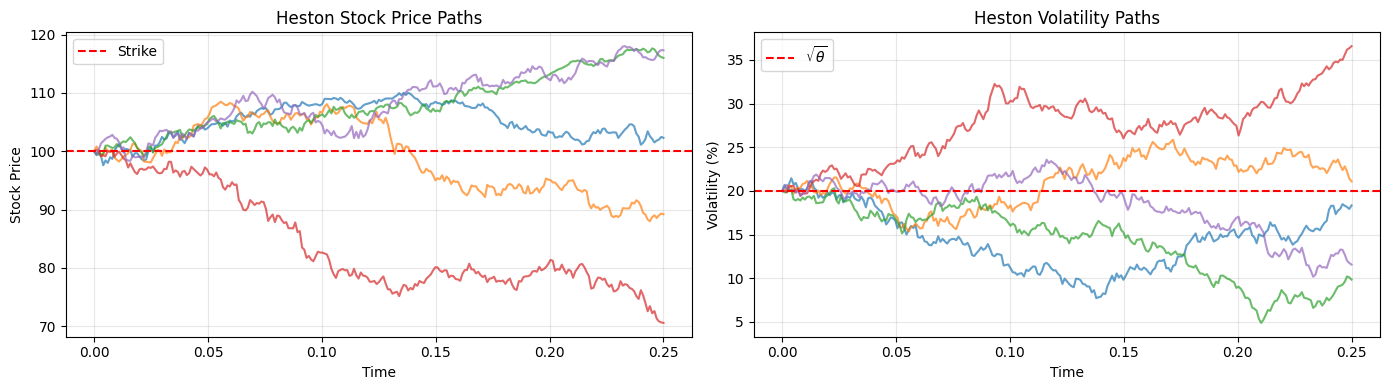

In [19]:
# Show example Heston paths
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

np.random.seed(123)
for _ in range(5):
    times, S, v = simulate_heston_path(S0, v0, r, kappa, theta, xi, rho, T, 252)
    axes[0].plot(times, S, alpha=0.7)
    axes[1].plot(times, 100*np.sqrt(v), alpha=0.7)

axes[0].axhline(K, color='r', linestyle='--', label='Strike')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Stock Price')
axes[0].set_title('Heston Stock Price Paths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(100*np.sqrt(theta), color='r', linestyle='--', label=r'$\sqrt{\theta}$')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('Heston Volatility Paths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## BS Delta vs Heston Delta

Here's the experiment: reality follows Heston, we sell an option and delta-hedge. We compare hedging with BS delta (using $\sigma = \sqrt{v_t}$) vs the full Heston delta.

Both methods observe the true variance at each hedge time. The question is whether knowing the full Heston dynamics—mean-reversion, vol-of-vol, correlation—actually improves the hedge.

We expect the unhedgeable vol risk to dominate the delta choice — let's see.

In [ ]:
def hedge_under_heston(S0, K, T, r, v0, kappa, theta, xi, rho, n_hedge, hedge_model='heston'):
    """ Delta-hedge a short call under Heston dynamics.
    hedge_model: 'heston' uses Heston delta, 'bs' uses BS delta with sqrt(v_t)
    """
    dt = T / n_hedge
    
    # Simulate Heston path
    times, S, v = simulate_heston_path(S0, v0, r, kappa, theta, xi, rho, T, n_hedge)
    
    # Initial option price (Heston price - this is what we receive)
    V0 = Heston_price(S0, K, T, r, kappa, v0, theta, xi, rho)
    
    # Get initial delta
    if hedge_model == 'heston':
        g = cos_greeks_full(S0, K, T, r, v0, model='heston', N=256, L=12,
                            heston_cf=Heston_CF, kappa=kappa, theta=theta, xi=xi, rho=rho)
        delta = g['delta']
    else:  # BS
        g = bs_greeks_analytical(S0, K, T, r, np.sqrt(v0), 'call')
        delta = g['delta']
    
    shares = delta
    cash = V0 - delta * S0
    
    portfolio_values = [V0]
    deltas_used = [delta]
    
    for i in range(1, n_hedge + 1):

        tau = T - times[i]
        cash *= np.exp(r * dt)
        
        portfolio_value = shares * S[i] + cash
        
        # Get new delta
        if tau > 1e-6:
            if hedge_model == 'heston':
                g = cos_greeks_full(S[i], K, tau, r, v[i], model='heston', N=256, L=12,
                                    heston_cf=Heston_CF, kappa=kappa, theta=theta, xi=xi, rho=rho)
                new_delta = g['delta']
            else:  # BS with current vol
                g = bs_greeks_analytical(S[i], K, tau, r, np.sqrt(v[i]), 'call')
                new_delta = g['delta']
        else:
            new_delta = 1.0 if S[i] > K else 0.0
        
        # Rebalance
        shares_traded = new_delta - shares
        cash -= shares_traded * S[i]
        shares = new_delta
        
        portfolio_values.append(portfolio_value)
        deltas_used.append(new_delta)
    
    # Final PnL
    payoff = max(S[-1] - K, 0)
    final_portfolio = shares * S[-1] + cash
    hedge_pnl = final_portfolio - payoff
    
    return {
        'times': times,
        'spot': S,
        'vol': v,
        'portfolio_values': np.array(portfolio_values),
        'deltas': np.array(deltas_used),
        'hedge_pnl': hedge_pnl,
        'payoff': payoff,
        'final_portfolio': final_portfolio
    }

In [21]:
# Run Monte Carlo comparison
n_paths = 500
n_hedge = 50

pnl_bs = []
pnl_heston = []

print("Running hedge comparison...")
for i in range(n_paths):
    np.random.seed(i)  # Same paths for fair comparison
    res_bs = hedge_under_heston(S0, K, T, r, v0, kappa, theta, xi, rho, n_hedge, 'bs')
    
    np.random.seed(i)
    res_h = hedge_under_heston(S0, K, T, r, v0, kappa, theta, xi, rho, n_hedge, 'heston')
    
    pnl_bs.append(res_bs['hedge_pnl'])
    pnl_heston.append(res_h['hedge_pnl'])

pnl_bs = np.array(pnl_bs)
pnl_heston = np.array(pnl_heston)

print("\nHedge PnL Statistics")
print("="*60)
print(f"{'Metric':<20} {'BS Delta':>18} {'Heston Delta':>18}")
print("-"*60)
print(f"{'Mean PnL':<20} {np.mean(pnl_bs):>18.4f} {np.mean(pnl_heston):>18.4f}")
print(f"{'Std PnL':<20} {np.std(pnl_bs):>18.4f} {np.std(pnl_heston):>18.4f}")
print(f"{'5th Percentile':<20} {np.percentile(pnl_bs, 5):>18.4f} {np.percentile(pnl_heston, 5):>18.4f}")
print(f"{'95th Percentile':<20} {np.percentile(pnl_bs, 95):>18.4f} {np.percentile(pnl_heston, 95):>18.4f}")

Running hedge comparison...

Hedge PnL Statistics
Metric                         BS Delta       Heston Delta
------------------------------------------------------------
Mean PnL                        -0.0424            -0.0426
Std PnL                          0.8005             0.8773
5th Percentile                  -1.5596            -1.6256
95th Percentile                  1.1424             1.1704


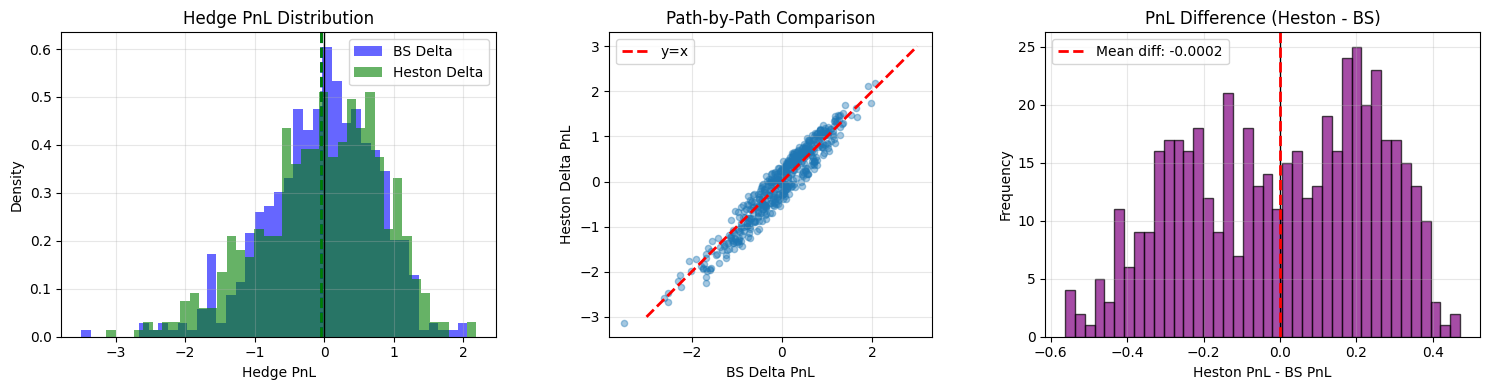


Key Finding:
  BS Delta std:     0.8005
  Heston Delta std: 0.8773
  Correlation:      0.9617

The high correlation shows both methods face the SAME underlying risk: vol moves.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PnL distributions
ax = axes[0]
ax.hist(pnl_bs, bins=40, alpha=0.6, label='BS Delta', density=True, color='blue')
ax.hist(pnl_heston, bins=40, alpha=0.6, label='Heston Delta', density=True, color='green')
ax.axvline(np.mean(pnl_bs), color='blue', linestyle='--', linewidth=2)
ax.axvline(np.mean(pnl_heston), color='green', linestyle='--', linewidth=2)
ax.axvline(0, color='k', linestyle='-', linewidth=1)
ax.set_xlabel('Hedge PnL')
ax.set_ylabel('Density')
ax.set_title('Hedge PnL Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# Scatter: BS vs Heston PnL
ax = axes[1]
ax.scatter(pnl_bs, pnl_heston, alpha=0.4, s=20)
ax.plot([-3, 3], [-3, 3], 'r--', linewidth=2, label='y=x')
ax.set_xlabel('BS Delta PnL')
ax.set_ylabel('Heston Delta PnL')
ax.set_title('Path-by-Path Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# PnL difference distribution
ax = axes[2]
pnl_diff = pnl_heston - pnl_bs
ax.hist(pnl_diff, bins=40, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(0, color='k', linestyle='-', linewidth=1)
ax.axvline(np.mean(pnl_diff), color='r', linestyle='--', linewidth=2, 
           label=f'Mean diff: {np.mean(pnl_diff):.4f}')
ax.set_xlabel('Heston PnL - BS PnL')
ax.set_ylabel('Frequency')
ax.set_title('PnL Difference (Heston - BS)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Finding:")
print(f"  BS Delta std:     {np.std(pnl_bs):.4f}")
print(f"  Heston Delta std: {np.std(pnl_heston):.4f}")
print(f"  Correlation:      {np.corrcoef(pnl_bs, pnl_heston)[0,1]:.4f}")
print(f"\nThe high correlation shows both methods face the SAME underlying risk: vol moves.")

PnL from both methods is highly correlated — the unhedgeable vol risk dominates the delta choice. Model choice matters more for exotics with strong path-dependence.

## The Unhedgeable Risk: Vol-of-Vol

Even with the correct Heston delta, risk remains. The option value depends on two state variables, $V = V(S_t, v_t, t)$, and the delta-hedged PnL is:

$$d\Pi = \frac{\partial V}{\partial v} dv + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}(dS)^2 + \frac{\partial V}{\partial t}dt$$

Stock hedges the $dS$ risk. But the $dv$ term—exposure to variance moves—requires other instruments: variance swaps, VIX options, or other vanilla options.

With only stock, the $dv$ exposure remains. And this exposure scales with $\xi$ (vol-of-vol): higher $\xi$ means more variance in variance, means more unhedgeable risk.

In [ ]:
# Test different vol-of-vol levels
xi_values = [0.1, 0.3, 0.5, 0.8]
n_paths_xi = 300

results_xi = {}

print("Testing vol-of-vol impact...")
for xi_test in xi_values:
    pnls = []
    for i in range(n_paths_xi):
        np.random.seed(i)
        res = hedge_under_heston(S0, K, T, r, v0, kappa, theta, xi_test, rho, n_hedge, 'heston')
        pnls.append(res['hedge_pnl'])
    results_xi[xi_test] = np.array(pnls)
    print(f"  xi={xi_test:.1f}: std={np.std(pnls):.4f}")

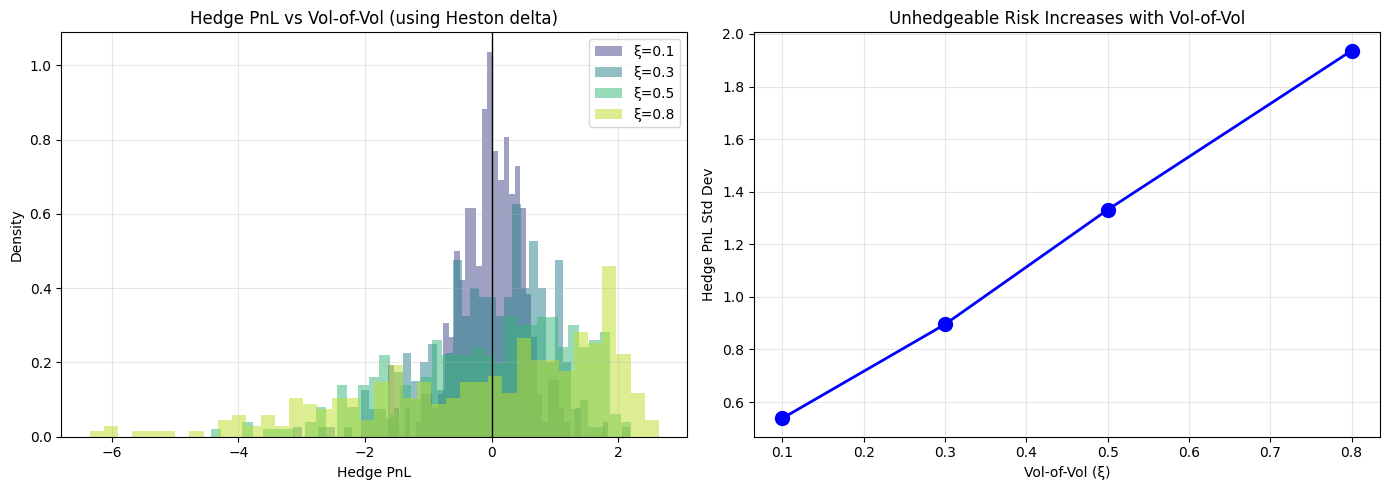

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PnL distributions for different xi
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(xi_values)))
for xi_test, color in zip(xi_values, colors):
    ax.hist(results_xi[xi_test], bins=40, alpha=0.5, label=f'ξ={xi_test}', 
            density=True, color=color)
ax.axvline(0, color='k', linestyle='-', linewidth=1)
ax.set_xlabel('Hedge PnL')
ax.set_ylabel('Density')
ax.set_title('Hedge PnL vs Vol-of-Vol (using Heston delta)')
ax.legend()
ax.grid(True, alpha=0.3)

# Std vs xi
ax = axes[1]
stds = [np.std(results_xi[xi]) for xi in xi_values]
ax.plot(xi_values, stds, 'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Vol-of-Vol (ξ)')
ax.set_ylabel('Hedge PnL Std Dev')
ax.set_title('Unhedgeable Risk Increases with Vol-of-Vol')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## The Leverage Effect

The correlation $\rho$ between stock returns and variance creates the leverage effect: when stock drops, vol tends to rise ($\rho < 0$). This creates negatively-skewed returns—the left tail is fatter.

For hedging, this is bad news. Large down moves coincide with vol spikes, so your hedge deteriorates exactly when you need it most. The PnL distribution becomes negatively skewed.

In [ ]:
# Compare different correlations
rho_values = [-0.9, -0.5, 0.0, 0.5]
n_paths_rho = 300

results_rho = {}

print("Testing correlation impact...")
for rho_test in rho_values:
    pnls = []
    for i in range(n_paths_rho):
        np.random.seed(i)
        res = hedge_under_heston(S0, K, T, r, v0, kappa, theta, xi, rho_test, n_hedge, 'heston')
        pnls.append(res['hedge_pnl'])
    results_rho[rho_test] = np.array(pnls)
    print(f"  rho={rho_test:+.1f}: mean={np.mean(pnls):.4f}, std={np.std(pnls):.4f}")

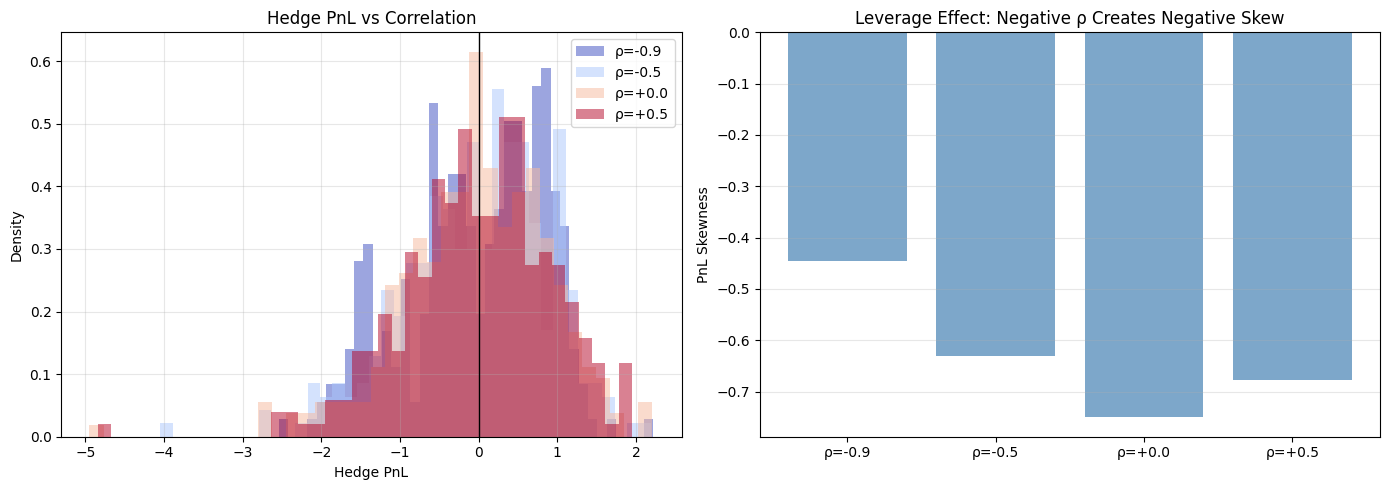

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rho_values)))
for rho_test, color in zip(rho_values, colors):
    ax.hist(results_rho[rho_test], bins=40, alpha=0.5, label=f'ρ={rho_test:+.1f}', 
            density=True, color=color)
ax.axvline(0, color='k', linestyle='-', linewidth=1)
ax.set_xlabel('Hedge PnL')
ax.set_ylabel('Density')
ax.set_title('Hedge PnL vs Correlation')
ax.legend()
ax.grid(True, alpha=0.3)

# Skewness vs rho
from scipy.stats import skew
ax = axes[1]
skews = [skew(results_rho[r]) for r in rho_values]
stds = [np.std(results_rho[r]) for r in rho_values]

ax.bar(range(len(rho_values)), skews, color='steelblue', alpha=0.7)
ax.set_xticks(range(len(rho_values)))
ax.set_xticklabels([f'ρ={r:+.1f}' for r in rho_values])
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.set_ylabel('PnL Skewness')
ax.set_title('Leverage Effect: Negative ρ Creates Negative Skew')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

For vanilla hedging, BS delta with current vol works nearly as well as Heston delta. The dominant risk is vol moves, which stock can't hedge — need variance swaps or other options for that.

TODO: add vega hedging with a second option to quantify how much residual risk drops.